#Classificação e aspectos experimentais (Parte I)

Fontes da aula de hoje:
1. Capítulos 22 do *Livro Data Mining and Machine Learning: Fundamental Concepts and Algorithms* (https://dataminingbook.info/book_html/)

3. Várias páginas da documentação da ``scikit-learn``

3. Aula do Professor Mark Crovella (https://github.com/mcrovella/CS506-Computational-Tools-for-Data-Science/blob/master/15-Classification-II-kNN.ipynb).

4. Várias figuras e definições extraídas de https://en.wikipedia.org/wiki/Precision_and_recall, https://en.wikipedia.org/wiki/Confusion_matrix e https://en.wikipedia.org/wiki/Receiver_operating_characteristic

# Introdução

## Nosso problema de interesse

Dados $D = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$, a tarefa de classificação consiste em encontrar um modelo $f$ que aprenda dos vetores de características os rótulos.

Há dois requisitos principais:

1. Se $(\mathbf{x}, y) \in D$, então $f(\mathbf{x}) = y$ com alta probabilidade.

2. A função aprendida deve ser **generalizável**. Se um novo $\mathbf{x}$ não pertencente ao conjunto $D$ for observado, deseja-se também que $f(\mathbf{x})$ seja o rótulo correto de $\mathbf{x}$ com alta probabilidade.

## Principais desafios experimentais

1. Como avaliar um classificador? **[Aula de hoje]**
2. Como escolher bons hiperparâmetros e evitar *overfitting*?

# Questão de hoje

**Entrada:**
1. Um classificador, $C$, já treinado
2. Um conjunto de dados rotulados, $T = \{(\mathbf{x}_i, y_i)\}_{i=1}^m$, que usaremos para avaliar $C$. $T$ é chamado de conjunto de **teste**.

**Saída:**
- Um conjunto de métricas e visualizações que vão nos permitir responder a pergunta "$C$ é um bom classificador para o conjunto $T$?"

## Mudando um pouco a pergunta

Vamos começar com um caso simples, o de classificação binária. Em outras palavras, $y_i \in \{0, 1\}$.

Dizemos que o rótulo 1 é a **classe positiva** e o rótulo 0 é a **classe negativa**.

Nosso primeiro passo será usar o classificador $C$ para "prever" os rótulos de $\mathbf{x}_1, \dots, \mathbf{x}_m$.

Vamos denotar por $\hat{y}_i$ a classe predita de $\mathbf{x}_i$. Em outras palavras:
$$\hat{y}_i = C(\mathbf{x}_i).$$

Dizer se $C$ é um bom classificador em $T$ é o mesmo que dizer o quão próximo o vetor $[y_1, \dots, y_m]^T$ está de $[\hat{y}_1, \dots, \hat{y}_m]^T$.

Alguma sugestão inicial?

# Matriz de confusão

## Definição

Como $y_i \in \{0, 1\}$ e $\hat{y}_i \in \{0,1\}$, nós temos quatro possíveis situações:
1. $y_i = 1$ e $\hat{y}_i = 1$, um **positivo verdadeiro**
2. $y_i = 0$ e $\hat{y}_i = 1$, um **positivo falso**
3. $y_i = 0$ e $\hat{y}_i = 0$, um **negativo verdadeiro**
4. $y_i = 1$ e $\hat{y}_i = 0$, um **negativo falso**.

Formalizando:
1. $TP = |\{(\mathbf{x}, y) \in T: y = 1 \text{ e } C(\mathbf{x}) = 1\}|$
2. $FP = |\{(\mathbf{x}, y) \in T: y = 0 \text{ e } C(\mathbf{x}) = 1\}|$
3. $TN = |\{(\mathbf{x}, y) \in T: y = 0 \text{ e } C(\mathbf{x}) = 0\}|$
4. $FN = |\{(\mathbf{x}, y) \in T: y = 1 \text{ e } C(\mathbf{x}) = 0\}|$

É conveniente organizar essas quantidades em uma matriz para facilitar a visualização:
$$
\begin{bmatrix}
TP & FN\\
FP & TN
\end{bmatrix}
$$

A matriz acima é chamada de **Matriz de Confusão** e é a fonte de uma variedade rica de métricas para avaliação de classificadores.

Da [Wikipedia](https://en.wikipedia.org/wiki/Confusion_matrix), temos a versão mais ilustrativa:

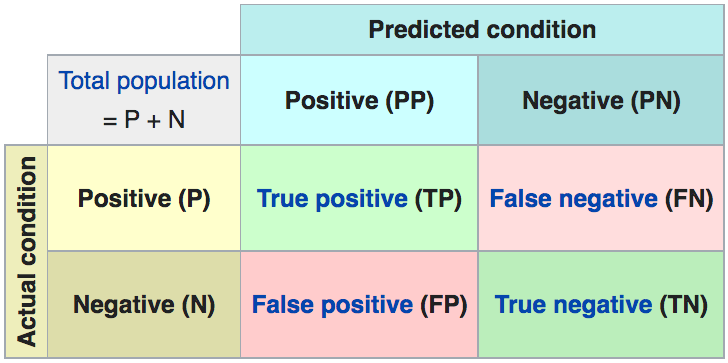

### Acurácia

Com as definições acima, podemos facilmente ver que a taxa de acerto do classificador, ou **acurácia**, é dada por:
$$
\text{Acurácia} = \frac{TP + TN}{TP + TN + FP + FN}.
$$

Vejamos um exemplo.

In [ ]:
#@title
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib as mp
import sklearn
from IPython.display import Image

from sklearn.neighbors import KNeighborsClassifier
import sklearn.datasets as datasets

X, y = datasets.make_circles(noise=.1, factor=.5, random_state=1)
#print('Shape of data: {}'.format(X.shape))
#print('Unique labels: {}'.format(np.unique(y)))

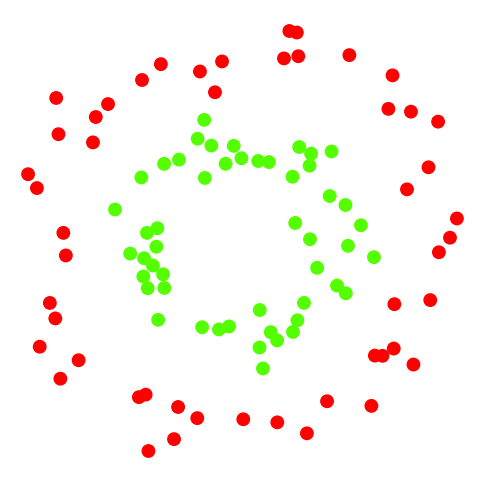

In [ ]:
#@title
plt.figure(figsize = (6,6))
plt.prism()  # this sets a nice color map
plt.scatter(X[:, 0], X[:, 1], c=y, s = 80)
plt.axis('off')
plt.axis('equal');

Considere que uma parte do dataset foi separada para treinar um **KNN** e outra é nosso conjunto de teste. Por hoje, não precisamos nos preocupar como essa divisão é feita.

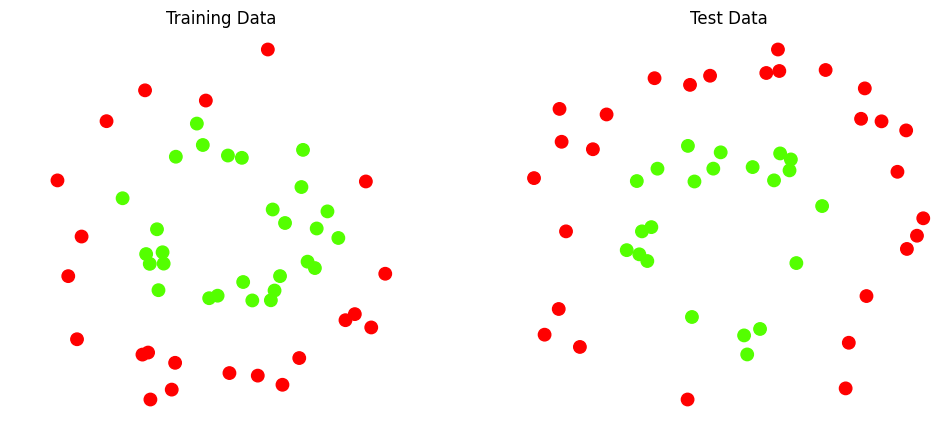

In [ ]:
#@title
X_train = X[:50]
y_train = y[:50]
X_test = X[50:]
y_test = y[50:]

fig_size = (12, 5)

plt.figure(figsize = fig_size)
plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c = y_train, s = 80)
plt.axis('equal')
plt.axis('off')
plt.title('Training Data')

plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_test, s = 80)
plt.title('Test Data')
plt.axis('equal')
plt.axis('off');

Treinando o classificador (Aula passada) em um conjunto de treinamento, ``X_train`` e ``y_train``.

In [ ]:
C = KNeighborsClassifier(n_neighbors = 3);
C.fit(X_train,y_train);

Predizendo os rótulos do conjunto de teste, ``X_test`` e ``y_test``.

In [ ]:
y_hat = C.predict(X_test)

Calculando a acurácia.

In [ ]:
from sklearn.metrics import accuracy_score

print('Acurácia', accuracy_score(y_test, y_hat))

Acurácia 0.92


### Visualizando a matriz de confusão

Com frequências...

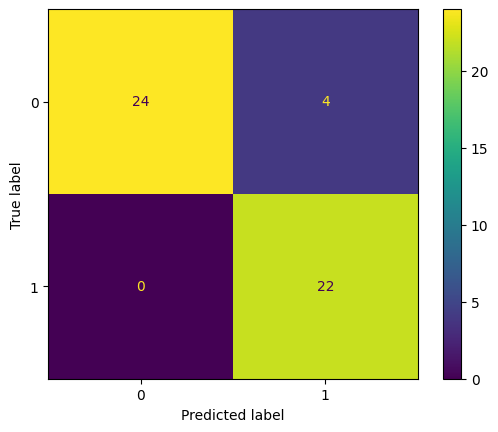

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_hat);

... e a normalizada.

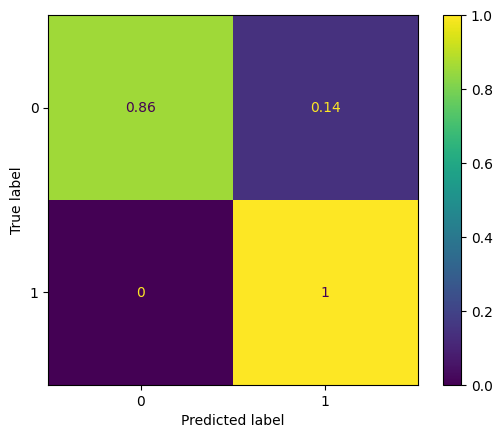

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_hat, normalize = 'true');

### Armadilha - Confiar apenas na acurácia

Para esse exemplo, vamos utilizar um conjunto de dados sintético.

In [ ]:
#@title Criação do Conjunto de Dados

import pandas as pd
from sklearn.datasets import make_classification

# criando um conjunto de dados extremamente desbalanceado
X, y = make_classification(n_samples = 1000, n_features = 5, n_classes = 2,
                           weights = [0.05, 0.95], random_state = 10)

df = pd.DataFrame(X, columns = ['Característica ' + str(i) for i in range(X.shape[1])])
df['Rótulo'] = y

O conjunto de dados possui 5 características. Os rótulos (ou classes) de cada um dos objetos é representado pela coluna ``Rótulo``.

In [ ]:
df.head()

,Característica 0,Característica 1,Característica 2,Característica 3,Característica 4,Rótulo
0,-0.216903,1.180622,0.531222,0.939646,-1.591588,1
1,1.037688,0.563244,-0.231997,-2.134521,1.322167,1
2,-0.070230,1.751403,0.681047,0.824625,-2.166129,0
3,0.602699,0.914540,0.083651,-1.016489,1.614958,1
4,-0.325737,1.917986,0.851671,1.466230,-0.414004,1


Abaixo, é definido um classificador simples (``SimpleClassifier``). A maneira como esse classificador funciona não é importante por agora.

In [ ]:
#@title Definição do Classificador
import numpy as np

# definindo um classificador simples que simplesmente associa todos
# os elementos a serem classificados com pertencentes à classe 1.
class SimpleClassifier():
  def __init__(self):
     pass

  def fit(self, X, y):
    pass

  def predict(self, X):
    return np.array([1] * X.shape[0])

Com isso, podemos seguir o procedimento de treinamento e avaliação visto nas aulas passadas! Incluindo:
- Divisão do conjunto de dados em subconjuntos para treinamento e teste;
- Transformação dos dados por reescala;
- Treinamento do classificador;
- Uso do classificador no conjunto de teste;
- Cômputo da acurácia do classificador.

Nesse momento, você já deve estar acostumando com essa sequência!

In [ ]:
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# obtendo os dados
X = df.drop('Rótulo', axis = 1)
y = df['Rótulo']

# devidindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30)

# Aplicando transformação por reescala
scaler = preprocessing.MinMaxScaler(feature_range = (0, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

# Ajustando o modelo
model = SimpleClassifier()
model.fit(X_train_scaled, y_train);

# Aplicando a mesma transformação nos dados de teste
X_test_scaled = scaler.transform(X_test)

# Realizando a previsão para os dados de teste
y_pred = model.predict(X_test_scaled);

# Medindo a acurácia do modelo nos dados de teste
acc = accuracy_score(y_test, y_pred)
print("Acurácia do Classificador = %f" % acc)

Acurácia do Classificador = 0.943333


Com o resultado encontrado acima, podemos perceber que o ``SimpleClassifier`` é um classificador adequado para o conjunto de dados gerado! **Isso é verdade, uma vez que a acurácia obtida é significativamente alta!**

**Será que isso é verdade mesmo?**

Vamos analisar com mais calma o que está acontecendo!

Primeiro, se você observar a definição do ``SimpleClassifier``, verá que o método ``fit`` não realiza nenhuma operação. **Já o método ``predict``, retorna a classe 1 para TODOS os elementos do conjunto de teste**.

Como que um classificador tão simples e ingênuo pode funcionar tão bem?

O segredo está no conjunto de dados sendo utilizado. O conjunto de dados é significativamente **desbalanceado**. Isso significa que uma das classes ocorre consideravelmente mais do que a outra.

Veja:

In [ ]:
y.mean()

np.float64(0.943)

Mais especificamente, aproximadamente 95% dos objetos do conjunto de dados são pertencentes à classe 1.

Ou seja, um classificador que simplesmente "chuta" a classe 1 para todos tem uma excelente acurácia. No entanto, caso o custo de um **falso positivo** seja muito alto, pode-se perceber que esse classificador é, na verdade, muito ruim!

Esse exemplo mostra que usar apenas a acurácia como métrica de avaliação de classificadores não é uma abordagem adequada.

Nas próximas aulas, veremos várias outras métricas para sanar esse problema.


### Lembrete

**MUITO CUIDADO COM A ACURÁCIA. PARA QUE ELA SEJA INFORMATIVA, DEVE-SE OBSERVAR TAMBÉM A PROPORÇÃO DE ELEMENTOS EM CADA CLASSE!!!**

## Precisão, Revocação e *F1-Score*

Para evitar a armadilha mencionada acima, precisamos de medidas auxiliares. As mais comuns são Precisão (*Precision*), revocação (*Recall*) e *F1-Score*.

Vamos começar com as definições:

1. $\text{Precision} = \frac{TP}{TP + FP}$

2. $\text{Recall} = \frac{TP}{TP + FN}$

3. $\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

### Interpretação

- A **Precisão** é a porcentagem de acertos entre todas as **predições para a classe positiva**.

- A **Revocação** é a porcentagem de acertos entre todos os **elementos da classe positiva**.

- O **F1-Score** é a média harmônica entre **precisão** e **revocação**.

As três medidas acima assumem valores entre 0 e 1. Quanto mais próximo de 1, melhor.


### Visualização

Da [Wikipedia](https://en.wikipedia.org/wiki/Precision_and_recall),

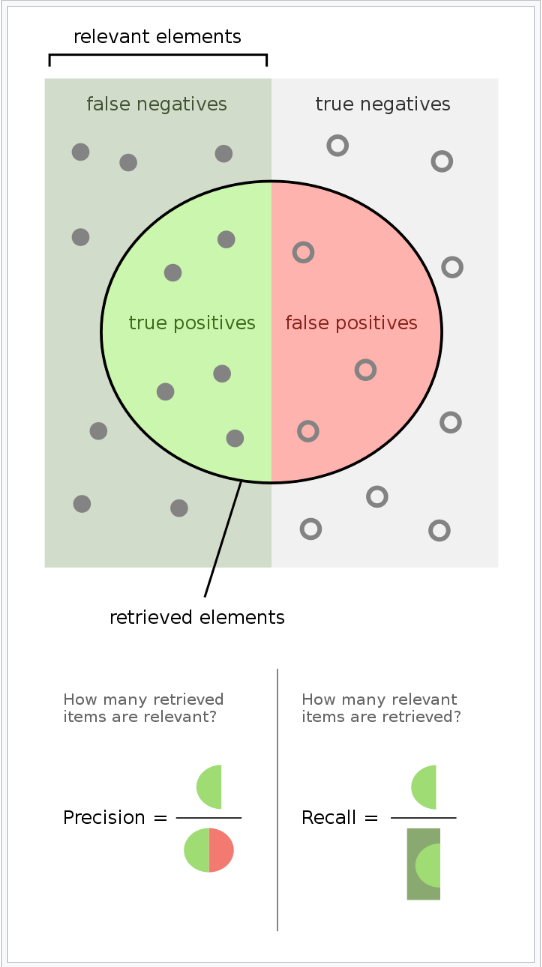

### Interpretação II

Suponham que vocês estejam vendo uma pessoa (e.g., um político) falar sobre um tema $x$.

- **Precisão:** de tudo que a pessoa falou, qual o percentual de verdades sobre $x$?
- **Revocação:** de todas as verdades sobre $x$, qual o percentual foi falado pela pessoa?

Um bom discurso sobre $x$ deve ser formado apenas por verdades (precisão) e deve conter todas as verdades (revocação).

### Na ``scikit-learn``

In [ ]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
print('Precisão:', precision_score(y_test, y_pred))

Precisão: 0.9433333333333334


In [ ]:
print('Revocação:', recall_score(y_test, y_pred))

Revocação: 1.0


In [ ]:
print('F1-Score:', f1_score(y_test, y_pred))

F1-Score: 0.9708404802744426


Podemos combinar todas as medidas com [``classification_report``](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.94      1.00      0.97       283

    accuracy                           0.94       300
   macro avg       0.47      0.50      0.49       300
weighted avg       0.89      0.94      0.92       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Classificadores não binários

Todas as definições acima podem ser generalizadas de forma natural para classificadores não binários (i.e., quando temos mais de duas classes). Vamos utlizar o dataset MNIST como exemplo.

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import datasets
import seaborn as sns

In [ ]:
digits = datasets.load_digits(return_X_y = False)
df = pd.DataFrame(digits.data)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


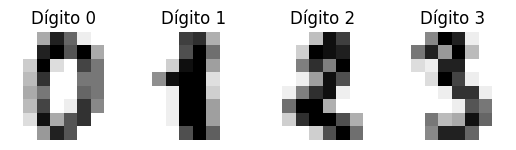

In [ ]:
images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:4]):
    plt.subplot(2, 4, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Dígito %i' % label)

Separando uma porção para treinar o classificador e outra para testar.

In [ ]:
import sklearn.model_selection as model_selection
X = digits.data
y = digits.target
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size = 0.33)

Treinando o classificador e predizendo os rótulos no conjunto de teste.

In [ ]:
C = KNeighborsClassifier(n_neighbors = 3) # 3
C.fit(X_train, y_train);
y_hat = C.predict(X_test)

Podemos proceder com a matriz de confusão normalmente (na versão de frequências ou normalizada).

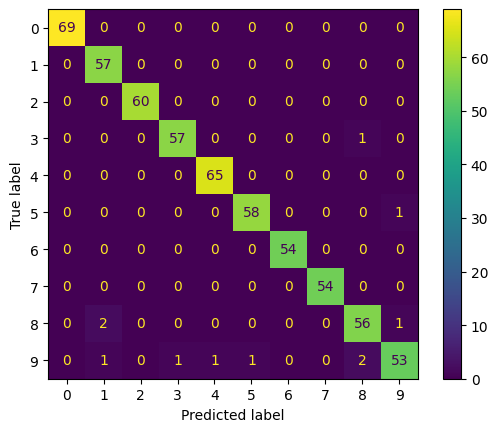

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_hat);

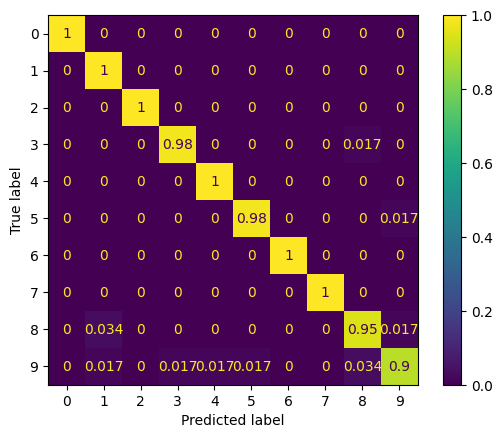

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_hat, normalize = 'true');

E podemos analisar **precisão**, **revocação** e **F1-Score** "como se cada uma das classes fosse a classe positiva".

In [ ]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        69
           1       0.95      1.00      0.97        57
           2       1.00      1.00      1.00        60
           3       0.98      0.98      0.98        58
           4       0.98      1.00      0.99        65
           5       0.98      0.98      0.98        59
           6       1.00      1.00      1.00        54
           7       1.00      1.00      1.00        54
           8       0.95      0.95      0.95        59
           9       0.96      0.90      0.93        59

    accuracy                           0.98       594
   macro avg       0.98      0.98      0.98       594
weighted avg       0.98      0.98      0.98       594



# Curva ROC e AUC

## Curva ROC

A Curva ROC (*Receiver Operating Characteristic*) é uma metodologia útil para analisar e avaliar classificadores em alguns contextos específicos.

Vamos supor que:

1. Estamos com um classificador $C$, já treinado para um problema de **classificação binária**.

2. Um conjunto de dados rotulados, $T = \{(\mathbf{x}_i, y_i)\}_{i=1}^m$, está disponível para avaliar o classificador.  $T$ é chamado de conjunto de **teste**.

3. Para cada $\mathbf{x}$, $C$ também consegue calcular um *score* que represente a chance de $\mathbf{x}$ ser da classe positiva.

Em geral, classificadores com essas propriedades funcionam da seguinte maneira. Um limiar $\rho$ é estabelecido e:
1. Itens com *score* maior que $\rho$ são classificados como sendo da classe positiva; e
2. Itens com *score* menor ou igual a $\rho$ são classificados como sendo da classe negativa.

### Exemplo I - KNN

O KNN satisfaz os requisitos acima. Quando queremos classificar um $\mathbf{x}$ com o KNN, o classificador:
1. Calcula a fração de elementos da classe positiva entre os $k$ vizinhos mais próximos de $\mathbf{x}$
2. Se a fração acima (*score*) for maior que $\rho = 0.5$, então a classe predita é positiva. Caso contrário, a classe predita é negativa.

E se mudássemos o valor do limiar utilizado? Vejamos um exemplo com um conjunto de dados sintético.

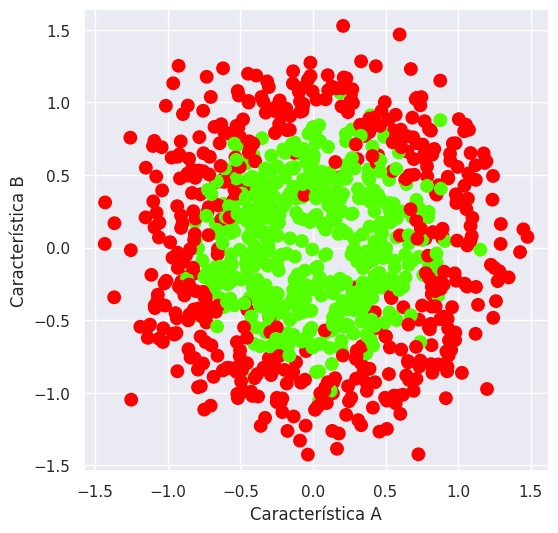

In [ ]:
#@title

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib as mp
import sklearn
from IPython.display import Image

import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
import sklearn.datasets as datasets

sns.set()

X, y = datasets.make_circles(n_samples = 1000, noise=.2, factor=.5, random_state=1)

plt.figure(figsize = (6,6))
plt.prism()  # this sets a nice color map
plt.scatter(X[:, 0], X[:, 1], c=y, s = 80)
#plt.axis('off')
plt.axis('equal')
plt.xlabel('Característica A')
plt.ylabel('Característica B');

Vamos dividir o conjunto em questão em subconjuntos de treinamento e teste.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30)

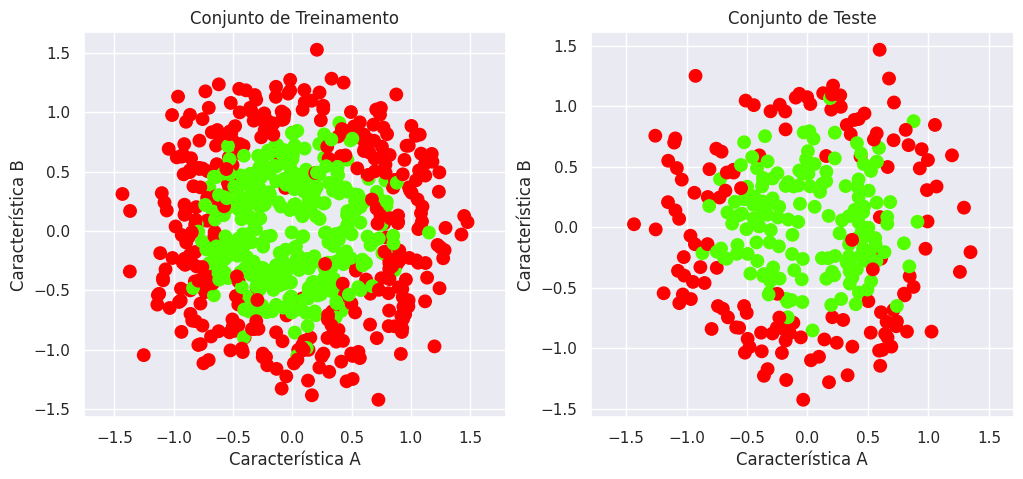

In [ ]:
#@title Conjuntos de Treinamento e Teste

fig_size = (12, 5)

plt.figure(figsize = fig_size)
plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c = y_train, s = 80)
plt.axis('equal')
plt.xlabel('Característica A')
plt.ylabel('Característica B');
plt.title('Conjunto de Treinamento')

plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_test, s = 80)
plt.title('Conjunto de Teste')
plt.axis('equal')
plt.xlabel('Característica A')
plt.ylabel('Característica B');

A título de exemplo, a seguir, treinamos um KNN com $k = 20$ no conjunto de treinamento.

In [ ]:
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# transformação por reescala
scaler = preprocessing.MinMaxScaler(feature_range = (0, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

# treinamento com k = 20
model = KNeighborsClassifier(n_neighbors = 20)
model.fit(X_train_scaled, y_train);

Para cada elemento $\mathbf{x}$ do conjunto de teste, ao invés de realizar a predição da classe do elemento, vamos calcular a fração de elementos pertencente a cada classe dentre os $k = 20$ mais próximos de $\mathbf{x}$ (no conjunto de treinamento).

In [ ]:
X_test_scaled = scaler.transform(X_test)
y_proba = model.predict_proba(X_test_scaled)

In [ ]:
y_proba

array([[0.9 , 0.1 ],
       [0.95, 0.05],
       [0.95, 0.05],
       [0.  , 1.  ],
       [0.3 , 0.7 ],
       [0.65, 0.35],
       [1.  , 0.  ],
       [0.65, 0.35],
       [0.55, 0.45],
       [1.  , 0.  ],
       [0.9 , 0.1 ],
       [0.95, 0.05],
       [0.9 , 0.1 ],
       [0.85, 0.15],
       [0.8 , 0.2 ],
       [0.  , 1.  ],
       [0.15, 0.85],
       [0.85, 0.15],
       [0.85, 0.15],
       [0.8 , 0.2 ],
       [0.4 , 0.6 ],
       [0.05, 0.95],
       [0.9 , 0.1 ],
       [0.  , 1.  ],
       [0.  , 1.  ],
       [0.  , 1.  ],
       [0.95, 0.05],
       [0.95, 0.05],
       [0.1 , 0.9 ],
       [1.  , 0.  ],
       [0.75, 0.25],
       [0.05, 0.95],
       [0.  , 1.  ],
       [0.25, 0.75],
       [0.1 , 0.9 ],
       [0.85, 0.15],
       [0.95, 0.05],
       [0.  , 1.  ],
       [0.95, 0.05],
       [0.1 , 0.9 ],
       [0.05, 0.95],
       [0.25, 0.75],
       [0.95, 0.05],
       [0.25, 0.75],
       [1.  , 0.  ],
       [0.05, 0.95],
       [0.15, 0.85],
       [0.3 ,

Assim, se usarmos o limiar de $\rho = 0.5$, para a segunda coluna da matriz acima, teremos o KNN padrão.

Vejamos isso no código abaixo.



In [ ]:
# Predizendo as classes dos elementos do conjunto de teste usando o limiar 0.5
rho = 0.5
y_pred_rho = [1 if x > rho else 0 for x in y_proba[:, 1]]

# Predizendo as classes dos elementos do conjunto de teste usando a função padrão da scikit-learn
y_pred = model.predict(X_test_scaled)

# verificando se os dois vetores são iguais em todas as posições.
(y_pred_rho == y_pred).all()

np.True_

Se considerarmos outros valores para $\rho$, o desempenho do classificador muda?

Vejamos o que acontece com o *F1-Score*.

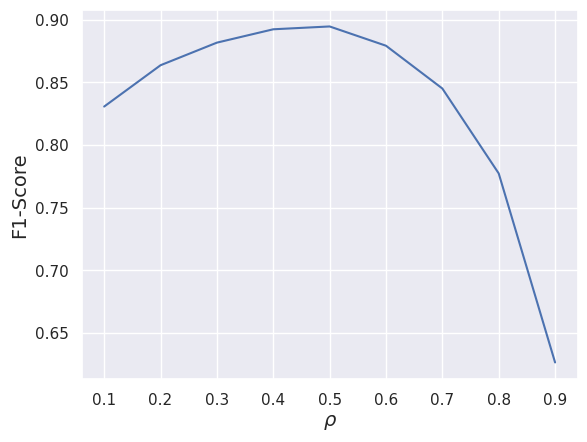

In [ ]:
from sklearn.metrics import f1_score

def compute_f1_score(rho):
  y_pred_rho = [1 if x > rho else 0 for x in y_proba[:, 1]]
  return f1_score(y_test, y_pred_rho)

rho = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
f1 = [compute_f1_score(x) for x in rho]

plt.plot(rho, f1)
plt.xlabel(r'$\rho$', fontsize=14)
plt.ylabel(r'F1-Score', fontsize=14);

### Curva ROC - Definição

Como motivado no exemplo acima, a curva ROC tem o objetivo de entender o comportamento de um classificador quando o limiar de classificação, $\rho$, é variado.

No entanto, isso não é feito avaliando-se o *F1-Score* em função de $\rho$.

Ao invés disso, para cada valor de $\rho$, os rótulos preditos são obtidos e as seguintes métricas de desempenho do classificador são calculadas:
1. *False Positive Rate* = $\frac{FP}{FP+TN}$; e
2. *True Positive Rate* = $\frac{TP}{TP+FN}$

Após isso, a Curva ROC é obtida ao se fazer o gráfico dos valores de TPR (*True Positive Rate*) e FPR (*False Positive Rate*) computados para diferentes valores de $\rho$.

No código abaixo, apresenta-se a Curva ROC para o Exemplo do KNN apresentando anteriormente, fazendo uso da biblioteca [``scikit-learn``](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html).




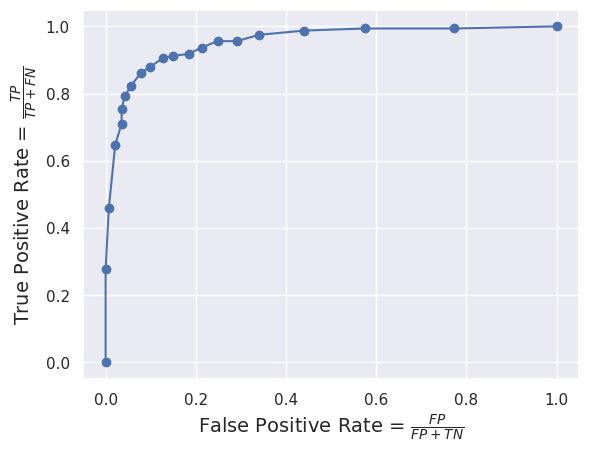

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, rhos = roc_curve(y_test, y_proba[:, 1])

plt.plot(fpr, tpr)
plt.scatter(fpr, tpr)
plt.xlabel(r'False Positive Rate = $\frac{FP}{FP+TN}$', fontsize=14)
plt.ylabel(r'True Positive Rate = $\frac{TP}{TP + FN}$', fontsize=14);

Na figura acima, cada "ponto" no gráfico é referente a um valor de $\rho$.

### Curva ROC - Interpretação

- A Curva ROC é sempre não decrescente.

- Um classificador perfeito ocorre quando TPR = 1 e FPR = 0, ou seja, quando a Curva ROC passa pelo canto superior esquerdo do gráfico.

- Assim, um bom classificador possui uma Curva ROC que "passa perto" do ponto (0, 1).

A Figura abaixo (Fonte: [Wikipedia](https://en.wikipedia.org/wiki/Receiver_operating_characteristic)) ilustra essa intuição.

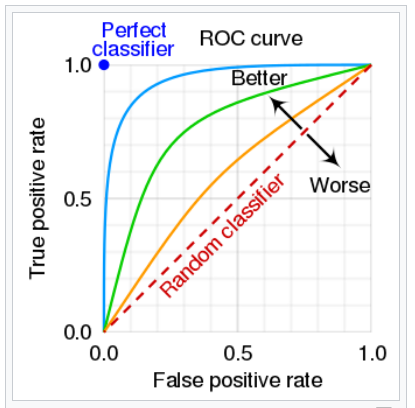

## AUC

A métrica AUC (*Area Under the Curve*) mede a área sob a Curva ROC.

Veja que, como um bom classificador possui curva ROC próxima ao ponto (0, 1), tem-se que, então, a área sob a curva ROC (AUC) será próxima de 1. À medida que esse valor decresce, há uma degradação do desempenho do classificador.

O código abaixo ilustra como a área sob a Curva ROC pode ser calculada utilizando a biblioteca [``scikit-learn``](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html).

Observe que a entrada para o método ``auc`` são os valores de FPR e TPR computados previamente.

In [ ]:
from sklearn.metrics import auc

print('AUC:', auc(fpr, tpr))

AUC: 0.9535884740621794


##Curva ROC e AUC em problemas multiclasse

As definições apresentadas para Curva ROC e AUC contemplam apenas casos de classificação binária.

É possível generalizar esses conceitos para problemas multiclasse. Aos interessados, recomenda-se a leitura do material disponível na documentação da biblioteca [``scikit-learn``](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html).

# What is next?

- Escolha de hiperparâmetros e *overfitting*
- Divisão do conjunto de dados em treino e teste.